# Preparación para funcionamiento correcto

In [2]:
import sys
import os
"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""
sys.path.append(os.path.abspath(".."))

## Fase 1: Setup + Exclusion de la variable target

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import skew, chi2_contingency
from src.imports.carga import cargar_csv

In [ ]:
df = cargar_csv("..\data\\raw\Student_Depression_Dataset_Original.csv")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\PC\AppData\Local\Temp\ipykernel_19408\923500800.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = cargar_csv("..\data\\raw\Student_Depression_Dataset_Original.csv")


### Fase 1.1: Identificacion variable target

In [ ]:
# Identificación de tipos de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

### Fase 1.2: Exclusion de variable target y otras que no se usaran

In [ ]:
df_copy=df.drop(['id', 'Depression'], axis=1)
df_target=df['Depression'] # Se guarda la variable Depresion por precaución
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  object 
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  object 
 10  Dietary Habits                         27901 non-null  object 
 11  De

### Fase 1.3: Revision de nulos

In [11]:
print(df_copy.isnull().sum())
print(df_copy.dtypes)

Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
dtype: int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA 

### Fase 1.4: Separacion de Columnas Numericas y Categoricas

In [14]:
numeric_cols = df_copy.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"COLUMNAS NUMÉRICAS ({len(numeric_cols)}):")
print(numeric_cols)
print(f"\nCOLUMNAS CATEGÓRICAS ({len(categorical_cols)}):")
print(categorical_cols)

COLUMNAS NUMÉRICAS (8):
['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

COLUMNAS CATEGÓRICAS (8):
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [17]:
print("\nDESCRIPCIÓN NUMÉRICAS")
df_copy[numeric_cols].describe()


DESCRIPCIÓN NUMÉRICAS


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000
mean,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867
std,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000


In [ ]:
print("\nDISTRIBUCIÓN CATEGÓRICAS")
for col in categorical_cols[:5]:  # Primeras 5 para no alargar
    print(f"\n{col}:")
    print(df_copy[col].value_counts().head(10))


=== DISTRIBUCIÓN CATEGÓRICAS (top 10) ===

Gender:
Gender
Male      15547
Female    12354
Name: count, dtype: int64

City:
City
Kalyan         1570
Srinagar       1372
Hyderabad      1340
Vasai-Virar    1290
Lucknow        1155
Thane          1139
Ludhiana       1111
Agra           1094
Surat          1078
Kolkata        1066
Name: count, dtype: int64

Profession:
Profession
Student             27870
Architect               8
Teacher                 6
Digital Marketer        3
Chef                    2
Content Writer          2
Pharmacist              2
Doctor                  2
UX/UI Designer          1
Civil Engineer          1
Name: count, dtype: int64

Sleep Duration:
Sleep Duration
Less than 5 hours    8310
7-8 hours            7346
5-6 hours            6183
More than 8 hours    6044
Others                 18
Name: count, dtype: int64

Dietary Habits:
Dietary Habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64


### Fase 1.5: Imputación de valores nulos

In [32]:
print("ANTES DE IMPUTAR")
print("Distribución Financial Stress:")
print(df['Financial Stress'].value_counts().sort_index())
print(f"Mediana: {df['Financial Stress'].mean()}")

ANTES DE IMPUTAR
Distribución Financial Stress:
Financial Stress
1.0    5121
2.0    5061
3.0    5226
4.0    5775
5.0    6715
Name: count, dtype: int64
Mediana: 3.1398666571080365


In [30]:
from sklearn.impute import SimpleImputer

# Imputar Financial Stress con mediana
imputer = SimpleImputer(strategy='median')
df_copy['Financial Stress'] = imputer.fit_transform(df_copy[['Financial Stress']])

print("Financial Stress después de imputar:")
print(df_copy['Financial Stress'].value_counts().sort_index())
print(f"Nulos restantes: {df_copy['Financial Stress'].isnull().sum()}")
print(f"Mediana: {df_copy['Financial Stress'].mean()}")

Financial Stress después de imputar:
Financial Stress
1.0    5121
2.0    5061
3.0    5229
4.0    5775
5.0    6715
Name: count, dtype: int64
Nulos restantes: 0
Mediana: 3.139851618221569


## Fase 1.6: Pipeline de Preprocesamiento Completo

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Pipeline para NUMÉRICAS
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Por si quedan más nulos
    ('scaler', StandardScaler())
])

# 2. Pipeline para CATEGÓRICAS
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Pipeline completo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 4. Ajustar y transformar
X_preprocessed = preprocessor.fit_transform(df_copy)

print(f"Forma original: {df_copy.shape}")
print(f"Forma después de preprocesamiento: {X_preprocessed.shape}")
print("Primeras filas del dataset preprocesado:")
print(pd.DataFrame(X_preprocessed).head())

Forma original: (27901, 16)
Forma después de preprocesamiento: (27901, 117)
Primeras filas del dataset preprocesado:
        0         1         2         3         4        5         6    \
0  1.463165  1.345543 -0.009777  0.893393 -0.693425 -0.01534 -1.121213   
1 -0.371474 -0.826104 -0.009777 -1.194076  1.510636 -0.01534 -1.121213   
2  1.055467 -0.102222 -0.009777 -0.425724  1.510636 -0.01534  0.497095   
3  0.443921 -0.102222 -0.009777 -1.404862 -0.693425 -0.01534 -0.851495   
4 -0.167625  0.621660 -0.009777  0.322229  0.041262 -0.01534 -1.660650   

        7    8    9    ...  107  108  109  110  111  112  113  114  115  116  
0 -1.488857  0.0  1.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0  
1 -0.793081  1.0  0.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0  
2 -1.488857  0.0  1.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0  
3  1.294246  1.0  0.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  
4 -1.488857  1.0  0.0  ...  0.0  0.0  0.0  

### Fase 1.6.5: Verificacion rapida

In [24]:
# Verificar que no hay nulos
print("¿Hay nulos en X_preprocessed?", np.isnan(X_preprocessed).sum())
print("Rango de valores:", X_preprocessed.min(), "a", X_preprocessed.max())

¿Hay nulos en X_preprocessed? 0
Rango de valores: -5.2058224884607345 a 113.64920578908021


## Fase 2: Clustering

In [25]:
## Fase 2: Clustering Analysis

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Buscar número óptimo de clusters (2 a 10)
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_preprocessed)
    silhouette_avg = silhouette_score(X_preprocessed, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}")

# 2. Elegir k óptimo
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nMejor k: {best_k} (Silhouette: {max(silhouette_scores):.3f})")

# 3. Entrenar modelo final
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_preprocessed)

print(f"\nDistribución de clusters: {np.bincount(cluster_labels)}")

k=2: Silhouette Score = 0.968
k=3: Silhouette Score = 0.088
k=4: Silhouette Score = 0.069
k=5: Silhouette Score = 0.065
k=6: Silhouette Score = 0.066
k=7: Silhouette Score = 0.063
k=8: Silhouette Score = 0.061
k=9: Silhouette Score = 0.061
k=10: Silhouette Score = 0.060

Mejor k: 2 (Silhouette: 0.968)

Distribución de clusters: [27899     2]


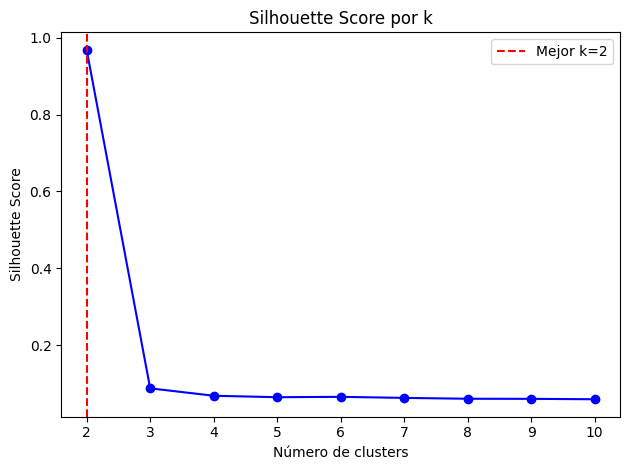

In [27]:
plt.plot(K_range, silhouette_scores, 'bo-')
plt.axvline(best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
plt.title('Silhouette Score por k')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

### Fase 2.1: Análisis e Interpretación de Clusters


In [33]:
# 1. Agregar clusters al dataframe
df_copy['Cluster'] = cluster_labels
df_copy['Depression'] = df_target

# 2. Tabla cruzada: Depression por Cluster
crosstab = pd.crosstab(df_copy['Cluster'], df_copy['Depression'], normalize='index') * 100
print("Porcentaje Depression por Cluster:")
print(crosstab.round(1))

# 3. Perfil numérico por cluster
print("Perfil Numérico por Cluster (promedios):")
cluster_profiles = df_copy.groupby('Cluster')[numeric_cols].mean().round(2)
print(cluster_profiles.T)  # Transpuesto para mejor lectura

Porcentaje Depression por Cluster:
Depression     0     1
Cluster               
0           41.4  58.6
1           50.0  50.0
Perfil Numérico por Cluster (promedios):
Cluster                 0     1
Age                 25.82  28.0
Academic Pressure    3.14   0.0
Work Pressure        0.00   5.0
CGPA                 7.66   0.0
Study Satisfaction   2.94   0.0
Job Satisfaction     0.00   4.0
Work/Study Hours     7.16   5.5
Financial Stress     3.14   3.5


| Aspecto               | Cluster 0 (más estudiantes)         | Cluster 1 (más trabajadores)   |
| --------------------- | ----------------------------------- | ------------------------------ |
| % Depresión           | 58.6% (más deprimidos)  | 50.0% (balanceado)             |
| Edad                  | 25.8 años                           | 28.0 años                      |
| Presión Académica     | Alta (3.14)                         | 0                              |
| Presión Laboral       | 0                                   | Alta (5.0)                     |
| CGPA                  | 7.66 (buen rendimiento)             | 0 (sin estudios o bajo)        |
| Satisfacción Estudios | 2.94                                | 0                              |
| Satisfacción Trabajo  | 0                                   | 4.0                            |
| Horas Trabajo/Estudio | 7.16                                | 5.5                            |
| Estrés Financiero     | 3.14                                | 3.5 (más alto) codificandobits |

### Fase 2.2: Guardar Resultados

In [37]:
import joblib

# Guardar todo
joblib.dump({
    'kmeans': kmeans_final,
    'preprocessor': preprocessor,
    'cluster_labels': cluster_labels,
    'best_k': best_k,
    'silhouette_scores': silhouette_scores
}, '../models/trained_models/clustering_pipeline_complete.pkl')

# Guardar perfiles para reporte
cluster_profiles.to_csv('../results/metrics/cluster_profiles.csv')
crosstab.to_csv('../results/metrics/depression_by_cluster.csv')


## Conclusiones Fase 1-2

**Hallazgos principales:**
1. **Cluster 0 (Estudiantes estresados)**: Alta presión académica → 58.6% depresión.
2. **Cluster 1 (Trabajadores sobrecargados)**: Alta presión laboral → 50% depresión.